# Genre Prediction — Comprehensive Experiment Comparison

This notebook runs **multiple experiment variants** on the same dataset, comparing different data cleaning strategies, null handling, genre filtering, and feature sets.

All experiments use the same 4 Naive Bayes models (Gaussian, Multinomial, Complement, Bernoulli) with grid search and 5-fold stratified CV.

---

## Experiments Overview

| # | Experiment | Features | Genre filter | Nulls | Extra |
|---|-----------|----------|-------------|-------|-------|
| 1 | Baseline | Numeric only | First genre (all rows) | Impute (median) | — |
| 2 | 80th-percentile genre | Numeric only | First genre, rare→'other' | Impute (median) | — |
| 3 | Deeper cleaning + drop nulls | Numeric only | First genre (all rows) | Drop rows | Outlier capping |
| 4a | Single-genre rows + impute | Numeric only | Only rows with 1 genre | Impute (median) | — |
| 4b | Single-genre rows + drop | Numeric only | Only rows with 1 genre | Drop rows | — |
| 5 | + Categorical (raw) | Numeric + categorical | First genre (all rows) | Impute / 'missing' | No treatment |
| 6a | + Categorical (treated) + impute | Numeric + treated cat. | First genre (all rows) | Impute / 'missing' | Top-1 actor, top-1 director… |
| 6b | + Categorical (treated) + drop | Numeric + treated cat. | First genre (all rows) | Drop rows | Top-1 actor, top-1 director… |
| 7 | Interaction features | Numeric + ratios | First genre (all rows) | Impute (median) | budget/runtime, votes ratio… |
| 8 | Kitchen sink (best of all) | All treated features | First genre, rare→'other' | Impute | Interactions + cat treated |


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, precision_score, classification_report

# Paths — adjust if needed
DATA_DIR = Path('./data')
RESULTS_DIR = Path('./results_comparison')
RESULTS_DIR.mkdir(exist_ok=True)

# File configuration (same as original)
FILE_CONFIG = {
    'TMDB IMDB Movies Dataset': {
        'filename': 'TMDB IMDB Movies Dataset.csv',
        'column_mappings': {'original_title': 'title'}
    },
    'merged_dataset': {
        'filename': 'merged_dataset.csv',
        'column_mappings': {
            'name': 'title', 'rating': 'vote_average',
            'num_raters': 'vote_count', 'run_length': 'runtime',
            'year': 'release_date'
        }
    }
}

USELESS_COLS = ['id', 'backdrop_path', 'poster_path', 'homepage', 'tconst', 'original_title']
NUMERIC_COLS = ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget',
                'popularity', 'averagerating', 'numvotes', 'num_reviews']
BOOLEAN_COLS = ['adult']
LIST_LIKE_COLS = ['genres', 'production_companies', 'production_countries',
                  'spoken_languages', 'keywords', 'directors', 'writers', 'cast']
EMPTY_COL_THRESHOLD = 0.8
EMPTY_ALIASES = ['unknown', 'unset', '', 'nan', 'none', 'n/a', 'na']

# Features we'll use across experiments
NUMERIC_FEATURES = ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes',
                    'vote_average', 'vote_count', 'budget', 'revenue']
# Categorical columns we'll try adding
CATEGORICAL_COLS = ['original_language', 'status']
# List-like columns we'll treat for categorical features
LIST_CAT_COLS = ['cast', 'directors', 'writers', 'production_companies',
                 'production_countries', 'spoken_languages']

RANDOM_STATE = 42
print("Configuration loaded.")


Configuration loaded.


## 1. Load & Clean Data (shared across all experiments)

In [2]:
# --- Load & merge ---
dfs = []
for name, config in FILE_CONFIG.items():
    fp = DATA_DIR / config['filename']
    print(f"Loading {fp}...")
    tmp = pd.read_csv(fp, low_memory=False)
    tmp.rename(columns=config['column_mappings'], inplace=True)
    tmp = tmp.loc[:, ~tmp.columns.duplicated()]
    tmp['_source'] = name
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Merged shape: {df_raw.shape}")

# --- Standardise column names ---
df_raw.columns = (
    df_raw.columns.str.strip().str.lower()
    .str.replace(r'[\s\-\.]+', '_', regex=True)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

# --- Drop useless columns ---
useless = [c.strip().lower().replace(' ', '_').replace('-', '_').replace('.', '_')
           for c in USELESS_COLS]
df_raw.drop(columns=[c for c in useless if c in df_raw.columns], inplace=True, errors='ignore')

# --- Drop highly empty columns (>=80%) ---
def calc_empty_ratio(s):
    is_empty = s.isna()
    if s.dtype == object:
        is_empty = is_empty | s.astype(str).str.strip().str.lower().isin(EMPTY_ALIASES)
    return is_empty.mean()

empty_ratios = df_raw.apply(calc_empty_ratio)
highly_empty = empty_ratios[empty_ratios >= EMPTY_COL_THRESHOLD].index
df_raw.drop(columns=highly_empty, inplace=True)
print(f"Dropped {len(highly_empty)} highly-empty columns: {list(highly_empty)}")

# --- Standardise strings ---
for col in df_raw.select_dtypes(include='object').columns:
    df_raw[col] = df_raw[col].astype(str).str.strip().str.lower()
    df_raw[col] = df_raw[col].replace(EMPTY_ALIASES, np.nan)
    df_raw[col] = df_raw[col].str.strip(';,| ')

# --- Drop rows with empty genres ---
df_raw = df_raw[df_raw['genres'].notna() & (df_raw['genres'].str.strip() != '')]
print(f"After dropping empty genres: {len(df_raw)} rows")

# --- Standardise numerics ---
for col in NUMERIC_COLS:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# --- Standardise booleans ---
for col in BOOLEAN_COLS:
    if col in df_raw.columns:
        df_raw[col] = (
            df_raw[col].astype(str).str.strip().str.lower()
            .map({'true':1,'false':0,'1':1,'0':0,'1.0':1,'0.0':0,'yes':1,'no':0})
        ).fillna(0).astype(int)

# --- Parse list-like columns ---
def parse_list(val):
    if pd.isna(val): return []
    val = str(val).strip()
    if not val: return []
    items = [x.strip() for x in val.replace(';', ',').split(',')]
    return [x for x in items if x and x not in EMPTY_ALIASES]

for col in LIST_LIKE_COLS:
    if col in df_raw.columns:
        df_raw[f'{col}_parsed'] = df_raw[col].apply(parse_list)
        df_raw[f'{col}_count'] = df_raw[f'{col}_parsed'].apply(len)

# --- Parse release_date into year/month ---
if 'release_date' in df_raw.columns:
    date_raw = df_raw['release_date'].astype(str).str.replace(r'\(.*?\)', '', regex=True).str.strip()
    parsed = pd.to_datetime(date_raw, format='%Y-%m-%d', errors='coerce')
    mask = parsed.isna()
    parsed[mask] = pd.to_datetime(date_raw[mask], format='mixed', errors='coerce')
    df_raw['release_year'] = parsed.dt.year
    df_raw['release_month'] = parsed.dt.month
    df_raw.drop(columns=['release_date'], inplace=True)

# --- Genre parsing ---
df_raw['genres_parsed'] = df_raw['genres'].apply(parse_list) if 'genres_parsed' not in df_raw.columns else df_raw['genres_parsed']
df_raw['genre_count'] = df_raw['genres_parsed'].apply(len)

print(f"\nCleaned dataset: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")


Loading data\TMDB IMDB Movies Dataset.csv...
Loading data\merged_dataset.csv...
Merged shape: (436935, 31)
Dropped 2 highly-empty columns: ['movie_rated', 'num_reviews']
After dropping empty genres: 357787 rows

Cleaned dataset: (357787, 42)
Columns: ['title', 'vote_average', 'vote_count', 'status', 'revenue', 'runtime', 'adult', 'budget', 'original_language', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'directors', 'writers', 'averagerating', 'numvotes', 'cast', '_source', 'genres_parsed', 'genres_count', 'production_companies_parsed', 'production_companies_count', 'production_countries_parsed', 'production_countries_count', 'spoken_languages_parsed', 'spoken_languages_count', 'keywords_parsed', 'keywords_count', 'directors_parsed', 'directors_count', 'writers_parsed', 'writers_count', 'cast_parsed', 'cast_count', 'release_year', 'release_month', 'genre_count']


## 2. Shared Training & Evaluation Functions

In [3]:
def get_model_configs():
    """Return the 4 NB model pipelines with grid search params."""
    return {
        'GaussianNB': {
            'pipeline': Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())]),
            'params': {'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4]}
        },
        'MultinomialNB': {
            'pipeline': Pipeline([('scaler', MinMaxScaler()), ('clf', MultinomialNB())]),
            'params': {'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0], 'clf__fit_prior': [True, False]}
        },
        'ComplementNB': {
            'pipeline': Pipeline([('scaler', MinMaxScaler()), ('clf', ComplementNB())]),
            'params': {'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0], 'clf__norm': [True, False]}
        },
        'BernoulliNB': {
            'pipeline': Pipeline([('scaler', MinMaxScaler()), ('clf', BernoulliNB())]),
            'params': {'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0], 'clf__binarize': [0.0, 0.25, 0.5, 0.75]}
        }
    }


def run_experiment(X, y, experiment_name, null_strategy='impute'):
    """
    Run all 4 NB models on given X, y.
    null_strategy: 'impute' (median for numeric, 'missing' for cat) or 'drop'
    Returns dict of results.
    """
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"{'='*70}")
    print(f"  Rows: {len(X)}, Features: {list(X.columns)}")
    print(f"  Classes: {y.nunique()}, Null strategy: {null_strategy}")

    # --- Prepare features ---
    X = X.copy()

    # Separate numeric and categorical
    num_cols = []
    cat_cols = []
    for col in X.columns:
        converted = pd.to_numeric(X[col], errors='coerce')
        if converted.isna().sum() <= X[col].isna().sum() + 5:  # tolerance for a few extra NaN
            X[col] = converted
            num_cols.append(col)
        else:
            cat_cols.append(col)

    # --- Null handling ---
    if null_strategy == 'drop':
        before = len(X)
        mask = X[num_cols].notna().all(axis=1) if num_cols else pd.Series(True, index=X.index)
        if cat_cols:
            mask = mask & X[cat_cols].notna().all(axis=1)
        X = X[mask]
        y = y[mask]
        print(f"  Dropped {before - len(X)} rows with nulls ({before - len(X)}/{before} = {(before-len(X))/before:.1%})")
        print(f"  Remaining: {len(X)} rows")
        if len(X) < 100:
            print("  *** TOO FEW ROWS — skipping experiment ***")
            return None
    else:
        # Impute
        for col in num_cols:
            X[col] = X[col].fillna(X[col].median())
        for col in cat_cols:
            X[col] = X[col].fillna('missing')

    # Label-encode categorical columns
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le

    # Fill any remaining NaN
    X = X.fillna(0)

    # Ensure all numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

    # --- Train/test split ---
    # Filter out classes with fewer than 2 samples
    class_counts = y.value_counts()
    valid_classes = class_counts[class_counts >= 5].index
    mask = y.isin(valid_classes)
    X, y = X[mask], y[mask]

    if len(X) < 50 or y.nunique() < 2:
        print("  *** TOO FEW SAMPLES/CLASSES — skipping ***")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # Impute with training medians only (avoid leakage) for the impute case
    if null_strategy == 'impute':
        train_medians = X_train.median()
        X_train = X_train.fillna(train_medians)
        X_test = X_test.fillna(train_medians)

    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)

    # --- Run models ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    model_configs = get_model_configs()
    exp_results = {}

    for model_name, config in model_configs.items():
        grid = GridSearchCV(
            config['pipeline'], config['params'],
            cv=cv, scoring='f1_weighted', n_jobs=-1, refit=True
        )
        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)

        f1 = f1_score(y_test, y_pred, average='weighted')
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)

        exp_results[model_name] = {
            'best_cv_f1': grid.best_score_,
            'test_f1': f1,
            'test_accuracy': acc,
            'test_precision': prec,
            'best_params': grid.best_params_,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_classes': y.nunique(),
            'n_features': X.shape[1],
        }
        print(f"  {model_name:15s} | CV F1={grid.best_score_:.4f} | Test F1={f1:.4f} | Acc={acc:.4f}")

    return exp_results


# Global results collector
ALL_RESULTS = {}

def store_results(experiment_name, exp_results):
    if exp_results is not None:
        ALL_RESULTS[experiment_name] = exp_results

print("Training functions ready.")


Training functions ready.


## 3. Genre Preparation Helpers

In [4]:
def prepare_first_genre(df):
    """Use the first genre listed for each movie."""
    df = df.copy()
    df['genre_label'] = df['genres_parsed'].apply(lambda lst: lst[0] if lst else np.nan)
    df = df[df['genre_label'].notna()]
    return df

def prepare_first_genre_80pct(df):
    """Use first genre, then group rare genres into 'other' (bottom 20% by count)."""
    df = prepare_first_genre(df)
    counts = df['genre_label'].value_counts()
    threshold = np.percentile(counts.values, 20)
    rare = counts[counts <= threshold].index.tolist()
    df['genre_label'] = df['genre_label'].apply(lambda g: 'other' if g in rare else g)
    print(f"  80th-pct grouping: threshold={threshold:.0f}, rare genres grouped: {rare}")
    return df

def prepare_single_genre_only(df):
    """Keep only rows where the movie has exactly 1 genre."""
    df = df.copy()
    df = df[df['genre_count'] == 1]
    df['genre_label'] = df['genres_parsed'].apply(lambda lst: lst[0] if lst else np.nan)
    df = df[df['genre_label'].notna()]
    print(f"  Single-genre filter: {len(df)} rows kept")
    return df

print("Genre helpers ready.")


Genre helpers ready.


## 4. Feature Engineering Helpers

In [5]:
def get_numeric_features(df):
    """Return only the numeric feature columns that exist."""
    available = [c for c in NUMERIC_FEATURES if c in df.columns]
    return df[available].copy()

def get_numeric_features_cleaned(df):
    """Numeric features with outlier capping (1st-99th percentile)."""
    X = get_numeric_features(df)
    for col in X.columns:
        if X[col].notna().sum() > 0:
            low = X[col].quantile(0.01)
            high = X[col].quantile(0.99)
            X[col] = X[col].clip(low, high)
    return X

def get_categorical_raw(df):
    """Return raw categorical columns (label-encoded later by run_experiment)."""
    available = [c for c in CATEGORICAL_COLS if c in df.columns]
    return df[available].copy()

def get_categorical_treated(df):
    """
    Treat list-like columns to extract the most popular (first listed) value,
    then keep only high-frequency categories (top 20), rest → 'other_cat'.
    """
    result = pd.DataFrame(index=df.index)

    for col in LIST_CAT_COLS:
        parsed_col = f'{col}_parsed'
        if parsed_col in df.columns:
            # Take first element (most prominent)
            result[f'{col}_top1'] = df[parsed_col].apply(
                lambda lst: lst[0] if lst else np.nan
            )
            # Group rare values
            counts = result[f'{col}_top1'].value_counts()
            top_vals = counts.head(20).index
            result[f'{col}_top1'] = result[f'{col}_top1'].apply(
                lambda x: x if x in top_vals else 'other_cat'
            )

    # Also add count features from list columns
    for col in LIST_CAT_COLS:
        count_col = f'{col}_count'
        if count_col in df.columns:
            result[count_col] = df[count_col]

    # Add raw categoricals too
    for col in CATEGORICAL_COLS:
        if col in df.columns:
            result[col] = df[col]

    return result

def get_interaction_features(df):
    """Create ratio/interaction features from numeric columns."""
    X = get_numeric_features(df)
    result = X.copy()

    # Budget per minute of runtime
    if 'budget' in X.columns and 'runtime' in X.columns:
        result['budget_per_minute'] = X['budget'] / X['runtime'].replace(0, np.nan)

    # Revenue to budget ratio (ROI proxy)
    if 'revenue' in X.columns and 'budget' in X.columns:
        result['revenue_budget_ratio'] = X['revenue'] / X['budget'].replace(0, np.nan)

    # Votes ratio TMDB/IMDB
    if 'vote_count' in X.columns and 'numvotes' in X.columns:
        result['tmdb_imdb_votes_ratio'] = X['vote_count'] / X['numvotes'].replace(0, np.nan)

    # Rating difference
    if 'vote_average' in X.columns and 'averagerating' in X.columns:
        result['rating_diff'] = X['vote_average'] - X['averagerating']

    # Popularity per vote
    if 'popularity' in X.columns and 'vote_count' in X.columns:
        result['popularity_per_vote'] = X['popularity'] / X['vote_count'].replace(0, np.nan)

    # Log transforms for highly skewed features
    for col in ['budget', 'revenue', 'popularity', 'vote_count', 'numvotes']:
        if col in X.columns:
            result[f'{col}_log'] = np.log1p(X[col].clip(lower=0))

    # Replace inf with NaN
    result.replace([np.inf, -np.inf], np.nan, inplace=True)

    return result

print("Feature engineering helpers ready.")


Feature engineering helpers ready.


## 5. Run All Experiments

---
### Experiment 1: Baseline (numeric features, impute nulls, first genre)
*Reproduces the original pipeline logic.*


In [6]:
df1 = prepare_first_genre(df_raw)
X1 = get_numeric_features(df1)
y1 = df1['genre_label']
store_results('1_baseline_numeric_impute', run_experiment(X1, y1, 'Baseline: numeric + impute'))



EXPERIMENT: Baseline: numeric + impute
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue']
  Classes: 21, Null strategy: impute
  GaussianNB      | CV F1=0.0555 | Test F1=0.0557 | Acc=0.1547
  MultinomialNB   | CV F1=0.1145 | Test F1=0.1144 | Acc=0.2694
  ComplementNB    | CV F1=0.1166 | Test F1=0.1159 | Acc=0.1909
  BernoulliNB     | CV F1=0.1619 | Test F1=0.1627 | Acc=0.2871


### Experiment 2: 80th percentile genre grouping (numeric, impute)

In [7]:
df2 = prepare_first_genre_80pct(df_raw)
X2 = get_numeric_features(df2)
y2 = df2['genre_label']
store_results('2_80pct_genre_impute', run_experiment(X2, y2, '80th-pct genre grouping + impute'))


  80th-pct grouping: threshold=3459, rare genres grouped: ['mystery', 'war', 'history', 'biography', 'sci-fi']

EXPERIMENT: 80th-pct genre grouping + impute
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue']
  Classes: 17, Null strategy: impute
  GaussianNB      | CV F1=0.0581 | Test F1=0.0582 | Acc=0.1563
  MultinomialNB   | CV F1=0.1145 | Test F1=0.1145 | Acc=0.2694
  ComplementNB    | CV F1=0.1167 | Test F1=0.1159 | Acc=0.1906
  BernoulliNB     | CV F1=0.1618 | Test F1=0.1627 | Acc=0.2875


### Experiment 3: Deeper numeric cleaning + drop nulls
*Outlier capping at 1st–99th percentile + drop rows with any null in features.*

First, let's study how many rows would be dropped.


In [8]:
df3 = prepare_first_genre(df_raw)
X3_raw = get_numeric_features_cleaned(df3)

# Study the null pattern
null_study = X3_raw.isna().sum().sort_values(ascending=False)
total = len(X3_raw)
print("Null counts per feature:")
for col, cnt in null_study.items():
    print(f"  {col}: {cnt} ({cnt/total:.1%})")

all_null_mask = X3_raw.notna().all(axis=1)
print(f"\nRows with NO nulls: {all_null_mask.sum()} / {total} ({all_null_mask.mean():.1%})")
print(f"Rows that would be dropped: {(~all_null_mask).sum()} ({(~all_null_mask).mean():.1%})")


Null counts per feature:
  release_year: 4709 (1.3%)
  runtime: 1500 (0.4%)
  averagerating: 1500 (0.4%)
  popularity: 1500 (0.4%)
  numvotes: 1500 (0.4%)
  revenue: 1500 (0.4%)
  budget: 1500 (0.4%)
  vote_count: 0 (0.0%)
  vote_average: 0 (0.0%)

Rows with NO nulls: 351578 / 357787 (98.3%)
Rows that would be dropped: 6209 (1.7%)


In [9]:
y3 = df3['genre_label']
store_results('3_cleaned_numeric_drop', run_experiment(X3_raw, y3, 'Cleaned numeric + drop nulls', null_strategy='drop'))



EXPERIMENT: Cleaned numeric + drop nulls
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue']
  Classes: 21, Null strategy: drop
  Dropped 6209 rows with nulls (6209/357787 = 1.7%)
  Remaining: 351578 rows
  GaussianNB      | CV F1=0.0765 | Test F1=0.0762 | Acc=0.1688
  MultinomialNB   | CV F1=0.1216 | Test F1=0.1215 | Acc=0.2704
  ComplementNB    | CV F1=0.1781 | Test F1=0.1755 | Acc=0.2492
  BernoulliNB     | CV F1=0.2195 | Test F1=0.2226 | Acc=0.2944


### Experiment 4a: Single-genre rows only + impute nulls
*Only keep movies that have exactly one genre — no ambiguity from multi-genre.*


In [10]:
df4 = prepare_single_genre_only(df_raw)
X4 = get_numeric_features(df4)
y4 = df4['genre_label']
store_results('4a_single_genre_impute', run_experiment(X4, y4, 'Single-genre only + impute'))


  Single-genre filter: 188028 rows kept

EXPERIMENT: Single-genre only + impute
  Rows: 188028, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue']
  Classes: 20, Null strategy: impute
  GaussianNB      | CV F1=0.0397 | Test F1=0.0380 | Acc=0.0345
  MultinomialNB   | CV F1=0.1532 | Test F1=0.1432 | Acc=0.1611
  ComplementNB    | CV F1=0.1584 | Test F1=0.1589 | Acc=0.2399
  BernoulliNB     | CV F1=0.2580 | Test F1=0.2614 | Acc=0.3091


### Experiment 4b: Single-genre rows only + drop nulls

In [11]:
store_results('4b_single_genre_drop', run_experiment(X4.copy(), y4.copy(), 'Single-genre only + drop', null_strategy='drop'))



EXPERIMENT: Single-genre only + drop
  Rows: 188028, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue']
  Classes: 20, Null strategy: drop
  Dropped 2778 rows with nulls (2778/188028 = 1.5%)
  Remaining: 185250 rows
  GaussianNB      | CV F1=0.0466 | Test F1=0.0455 | Acc=0.0374
  MultinomialNB   | CV F1=0.1444 | Test F1=0.1323 | Acc=0.1497
  ComplementNB    | CV F1=0.1573 | Test F1=0.1585 | Acc=0.2394
  BernoulliNB     | CV F1=0.2618 | Test F1=0.2598 | Acc=0.3069


### Experiment 5: Add raw categorical columns (no treatment)
*Add `original_language` and `status` as-is (label-encoded by the training function).*


In [12]:
df5 = prepare_first_genre(df_raw)
X5_num = get_numeric_features(df5)
X5_cat = get_categorical_raw(df5)
X5 = pd.concat([X5_num, X5_cat], axis=1)
y5 = df5['genre_label']
store_results('5_with_raw_cat_impute', run_experiment(X5, y5, 'Numeric + raw categorical + impute'))



EXPERIMENT: Numeric + raw categorical + impute
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'original_language', 'status']
  Classes: 21, Null strategy: impute
  GaussianNB      | CV F1=0.0543 | Test F1=0.0543 | Acc=0.1560
  MultinomialNB   | CV F1=0.1145 | Test F1=0.1144 | Acc=0.2694
  ComplementNB    | CV F1=0.2061 | Test F1=0.2048 | Acc=0.2529
  BernoulliNB     | CV F1=0.1625 | Test F1=0.1638 | Acc=0.2735


### Experiment 6a: Add treated categorical columns + impute
*Extract top-1 value from list columns (e.g. lead actor, primary director), group rare values, add count features.*


In [13]:
df6 = prepare_first_genre(df_raw)
X6_num = get_numeric_features(df6)
X6_cat = get_categorical_treated(df6)
X6 = pd.concat([X6_num, X6_cat], axis=1)
y6 = df6['genre_label']
print(f"Feature count: {X6.shape[1]} features")
print(f"Features: {list(X6.columns)}")
store_results('6a_treated_cat_impute', run_experiment(X6, y6, 'Numeric + treated categorical + impute'))


Feature count: 23 features
Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'cast_top1', 'directors_top1', 'writers_top1', 'production_companies_top1', 'production_countries_top1', 'spoken_languages_top1', 'cast_count', 'directors_count', 'writers_count', 'production_companies_count', 'production_countries_count', 'spoken_languages_count', 'original_language', 'status']

EXPERIMENT: Numeric + treated categorical + impute
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'cast_top1', 'directors_top1', 'writers_top1', 'production_companies_top1', 'production_countries_top1', 'spoken_languages_top1', 'cast_count', 'directors_count', 'writers_count', 'production_companies_count', 'production_countries_count', 'spoken_languages_count', 'original_language', 'status']
  Classes: 21, Null strategy: impute
  Gaussian

### Experiment 6b: Treated categorical + drop nulls

In [14]:
store_results('6b_treated_cat_drop', run_experiment(
    X6.copy(), y6.copy(), 'Numeric + treated categorical + drop', null_strategy='drop'))



EXPERIMENT: Numeric + treated categorical + drop
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'cast_top1', 'directors_top1', 'writers_top1', 'production_companies_top1', 'production_countries_top1', 'spoken_languages_top1', 'cast_count', 'directors_count', 'writers_count', 'production_companies_count', 'production_countries_count', 'spoken_languages_count', 'original_language', 'status']
  Classes: 21, Null strategy: drop
  Dropped 6209 rows with nulls (6209/357787 = 1.7%)
  Remaining: 351578 rows
  GaussianNB      | CV F1=0.0957 | Test F1=0.0977 | Acc=0.1440
  MultinomialNB   | CV F1=0.1820 | Test F1=0.1805 | Acc=0.1862
  ComplementNB    | CV F1=0.2412 | Test F1=0.2416 | Acc=0.3141
  BernoulliNB     | CV F1=0.2634 | Test F1=0.2641 | Acc=0.3310


### Experiment 7: Interaction / engineered features (numeric only)
*Add ratio features, log transforms, and other derived numeric features.*


In [15]:
df7 = prepare_first_genre(df_raw)
X7 = get_interaction_features(df7)
y7 = df7['genre_label']
print(f"Feature count: {X7.shape[1]} features")
print(f"Features: {list(X7.columns)}")
store_results('7_interactions_impute', run_experiment(X7, y7, 'Interaction features + impute'))


Feature count: 19 features
Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'budget_per_minute', 'revenue_budget_ratio', 'tmdb_imdb_votes_ratio', 'rating_diff', 'popularity_per_vote', 'budget_log', 'revenue_log', 'popularity_log', 'vote_count_log', 'numvotes_log']

EXPERIMENT: Interaction features + impute
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'budget_per_minute', 'revenue_budget_ratio', 'tmdb_imdb_votes_ratio', 'rating_diff', 'popularity_per_vote', 'budget_log', 'revenue_log', 'popularity_log', 'vote_count_log', 'numvotes_log']
  Classes: 21, Null strategy: impute
  GaussianNB      | CV F1=0.0570 | Test F1=0.0567 | Acc=0.1381
  MultinomialNB   | CV F1=0.1204 | Test F1=0.1200 | Acc=0.2701
  ComplementNB    | CV F1=0.1151 | Test F1=0.1146 | Acc=0.2033
  BernoulliNB     | CV F1=0.1808 | Test F1=0.1

### Experiment 8: Kitchen sink — best of everything
*80th-pct genre grouping + outlier-capped numerics + treated categoricals + interaction features + impute.*


In [16]:
df8 = prepare_first_genre_80pct(df_raw)
X8_num = get_numeric_features_cleaned(df8)
X8_cat = get_categorical_treated(df8)
X8_inter = get_interaction_features(df8)
# Merge all (avoid duplicate columns)
X8 = pd.concat([X8_inter, X8_cat], axis=1)
X8 = X8.loc[:, ~X8.columns.duplicated()]
y8 = df8['genre_label']
print(f"Feature count: {X8.shape[1]} features")
print(f"Features: {list(X8.columns)}")
store_results('8_kitchen_sink', run_experiment(X8, y8, 'Kitchen sink (all features + 80pct genre)'))


  80th-pct grouping: threshold=3459, rare genres grouped: ['mystery', 'war', 'history', 'biography', 'sci-fi']
Feature count: 33 features
Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'budget_per_minute', 'revenue_budget_ratio', 'tmdb_imdb_votes_ratio', 'rating_diff', 'popularity_per_vote', 'budget_log', 'revenue_log', 'popularity_log', 'vote_count_log', 'numvotes_log', 'cast_top1', 'directors_top1', 'writers_top1', 'production_companies_top1', 'production_countries_top1', 'spoken_languages_top1', 'cast_count', 'directors_count', 'writers_count', 'production_companies_count', 'production_countries_count', 'spoken_languages_count', 'original_language', 'status']

EXPERIMENT: Kitchen sink (all features + 80pct genre)
  Rows: 357787, Features: ['runtime', 'averagerating', 'release_year', 'popularity', 'numvotes', 'vote_average', 'vote_count', 'budget', 'revenue', 'budget_per_minute', 'revenue_budget_rati

## 6. Results Comparison

In [17]:
# Build comparison DataFrame
rows = []
for exp_name, models in ALL_RESULTS.items():
    for model_name, metrics in models.items():
        rows.append({
            'experiment': exp_name,
            'model': model_name,
            'cv_f1': metrics['best_cv_f1'],
            'test_f1': metrics['test_f1'],
            'test_acc': metrics['test_accuracy'],
            'test_prec': metrics['test_precision'],
            'n_train': metrics['n_train'],
            'n_test': metrics['n_test'],
            'n_classes': metrics['n_classes'],
            'n_features': metrics['n_features'],
        })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(RESULTS_DIR / 'full_comparison.csv', index=False)

# --- Best model per experiment ---
best_per_exp = comparison_df.loc[comparison_df.groupby('experiment')['test_f1'].idxmax()]
best_per_exp = best_per_exp.sort_values('test_f1', ascending=False)

print("=" * 80)
print("BEST MODEL PER EXPERIMENT (sorted by Test F1)")
print("=" * 80)
display(best_per_exp[['experiment', 'model', 'cv_f1', 'test_f1', 'test_acc', 'test_prec',
                       'n_train', 'n_classes', 'n_features']].to_string(index=False))


BEST MODEL PER EXPERIMENT (sorted by Test F1)


'               experiment        model    cv_f1  test_f1  test_acc  test_prec  n_train  n_classes  n_features\n           8_kitchen_sink  BernoulliNB 0.264504 0.265257  0.323164   0.247015   286229         17          33\n      6b_treated_cat_drop  BernoulliNB 0.263375 0.264069  0.331048   0.289790   281262         19          23\n    6a_treated_cat_impute  BernoulliNB 0.262915 0.262228  0.329290   0.261625   286227         20          23\n   4a_single_genre_impute  BernoulliNB 0.258005 0.261418  0.309126   0.226511   150421         19           9\n     4b_single_genre_drop  BernoulliNB 0.261832 0.259785  0.306856   0.225234   148200         19           9\n   3_cleaned_numeric_drop  BernoulliNB 0.219483 0.222620  0.294442   0.203176   281262         19           9\n    5_with_raw_cat_impute ComplementNB 0.206065 0.204788  0.252931   0.212793   286227         20          11\n    7_interactions_impute  BernoulliNB 0.180762 0.180771  0.254105   0.182658   286227         20          19\n

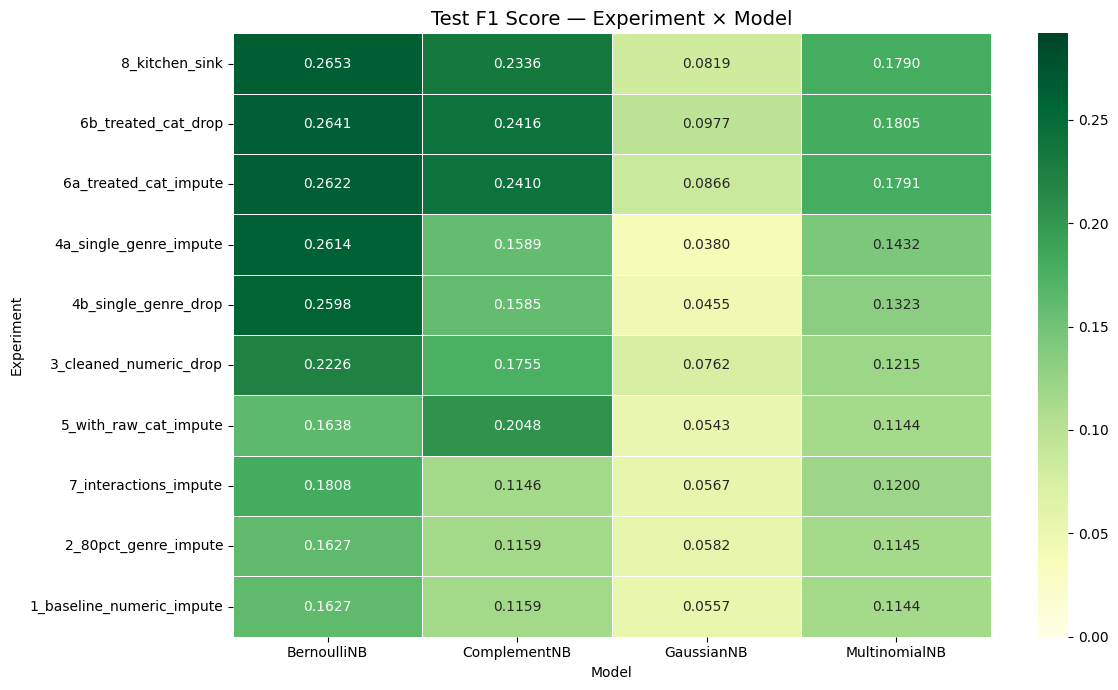

In [18]:
# --- Heatmap: Test F1 by experiment × model ---
pivot = comparison_df.pivot_table(index='experiment', columns='model', values='test_f1')
pivot = pivot.reindex(best_per_exp['experiment'])  # sort by best F1

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot) * 0.7)))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0, vmax=pivot.max().max() * 1.1)
ax.set_title('Test F1 Score — Experiment × Model', fontsize=14)
ax.set_ylabel('Experiment')
ax.set_xlabel('Model')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


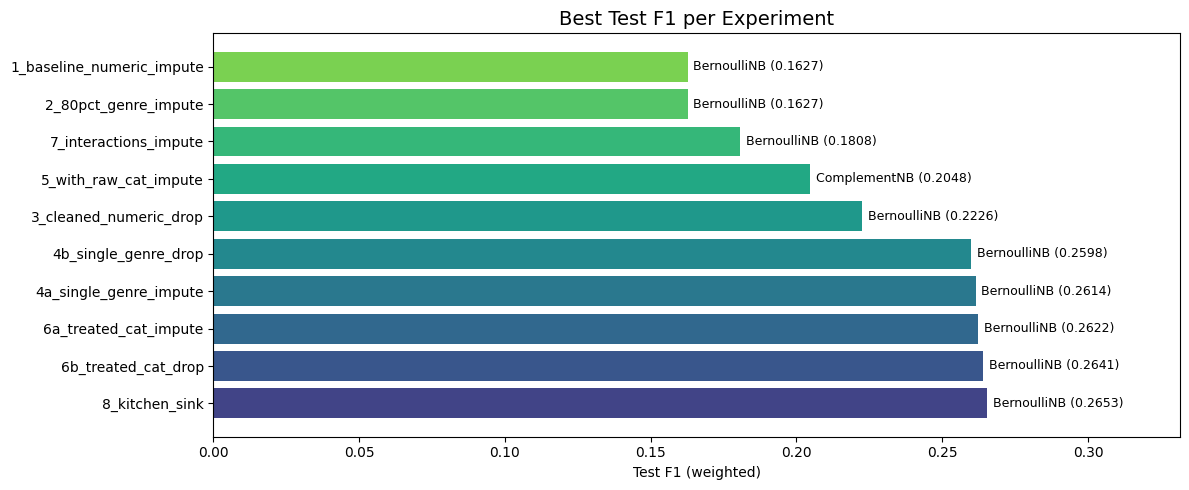

In [19]:
# --- Bar chart: best F1 per experiment ---
fig, ax = plt.subplots(figsize=(12, max(5, len(best_per_exp) * 0.5)))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(best_per_exp)))
bars = ax.barh(best_per_exp['experiment'], best_per_exp['test_f1'], color=colors)

# Add model name annotations
for bar, model in zip(bars, best_per_exp['model']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{model} ({bar.get_width():.4f})', va='center', fontsize=9)

ax.set_xlabel('Test F1 (weighted)')
ax.set_title('Best Test F1 per Experiment', fontsize=14)
ax.set_xlim(0, best_per_exp['test_f1'].max() * 1.25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# --- Detailed comparison table ---
print("\n" + "=" * 80)
print("FULL RESULTS TABLE")
print("=" * 80)
full_pivot = comparison_df.pivot_table(
    index='experiment', columns='model',
    values=['test_f1', 'test_acc', 'cv_f1']
)
display(full_pivot.style.format('{:.4f}').background_gradient(cmap='YlGn', axis=None))



FULL RESULTS TABLE


## 7. Key Takeaways

The cell below summarises what worked and what didn't.


In [21]:
# Automated takeaways
print("=" * 80)
print("AUTOMATED ANALYSIS")
print("=" * 80)

overall_best = best_per_exp.iloc[0]
baseline = ALL_RESULTS.get('1_baseline_numeric_impute', {})
baseline_best_f1 = max((v['test_f1'] for v in baseline.values()), default=0) if baseline else 0

print(f"\nBaseline best F1: {baseline_best_f1:.4f}")
print(f"Overall best F1:  {overall_best['test_f1']:.4f} ({overall_best['experiment']}, {overall_best['model']})")
print(f"Improvement:      {overall_best['test_f1'] - baseline_best_f1:+.4f} ({(overall_best['test_f1']-baseline_best_f1)/max(baseline_best_f1,1e-9)*100:+.1f}%)")

print("\n--- Observations ---")
for exp_name in best_per_exp['experiment']:
    exp_data = ALL_RESULTS[exp_name]
    best_model = max(exp_data, key=lambda m: exp_data[m]['test_f1'])
    f1 = exp_data[best_model]['test_f1']
    diff = f1 - baseline_best_f1
    n = exp_data[best_model]['n_train']
    nf = exp_data[best_model]['n_features']
    emoji = "+" if diff > 0 else "-" if diff < 0 else "="
    print(f"  [{emoji}] {exp_name}: F1={f1:.4f} (delta={diff:+.4f}), {n} train rows, {nf} features")

print("\n--- Recommendations ---")
print("• If adding categorical features improves F1, consider more granular groupings")
print("• If interaction features help, try polynomial feature combinations")
print("• If single-genre filtering helps, the multi-genre ambiguity is hurting the model")
print("• Next steps beyond NB: try tree-based models (Random Forest, XGBoost) which")
print("  handle mixed feature types and non-linear relationships much better")
print("• Consider frequency / TF-IDF encoding for list columns instead of just top-1")


AUTOMATED ANALYSIS

Baseline best F1: 0.1627
Overall best F1:  0.2653 (8_kitchen_sink, BernoulliNB)
Improvement:      +0.1026 (+63.1%)

--- Observations ---
  [+] 8_kitchen_sink: F1=0.2653 (delta=+0.1026), 286229 train rows, 33 features
  [+] 6b_treated_cat_drop: F1=0.2641 (delta=+0.1014), 281262 train rows, 23 features
  [+] 6a_treated_cat_impute: F1=0.2622 (delta=+0.0996), 286227 train rows, 23 features
  [+] 4a_single_genre_impute: F1=0.2614 (delta=+0.0988), 150421 train rows, 9 features
  [+] 4b_single_genre_drop: F1=0.2598 (delta=+0.0971), 148200 train rows, 9 features
  [+] 3_cleaned_numeric_drop: F1=0.2226 (delta=+0.0600), 281262 train rows, 9 features
  [+] 5_with_raw_cat_impute: F1=0.2048 (delta=+0.0421), 286227 train rows, 11 features
  [+] 7_interactions_impute: F1=0.1808 (delta=+0.0181), 286227 train rows, 19 features
  [+] 2_80pct_genre_impute: F1=0.1627 (delta=+0.0000), 286229 train rows, 9 features
  [=] 1_baseline_numeric_impute: F1=0.1627 (delta=+0.0000), 286227 train 